# Monte Carlo stress test — combined portfolio under resampled histories

Stress-tests `combined.ipynb`'s hand-picked combination -- **MES + M2K + M6A**, ~1
contract of each (see `combined.ipynb` for the weight derivation), `max_leverage=2`
-- against N=1000 alternate histories built by **block-bootstrapping the real
historical bars**, not a memoryless random walk. A plain i.i.d. random walk has ~zero
expected edge for a trend-following crossover by construction (no
autocorrelation/trend persistence to catch), so it would mostly test "what happens
when there's provably no structure," which isn't the interesting question here;
resampling contiguous real blocks preserves real autocorrelation/volatility-
clustering/trend-persistence while still randomizing which periods appear and in
what order.

**Why this combination, not the earlier MNQ+6J+M6A one**: that combination was
picked by an automated 20-combination Sharpe search and looked excellent in the real
historical run (Sharpe 2.34) -- but *this same Monte Carlo technique*, run against
it, found a 60% breach rate: the real result was a lucky draw, not a representative
one, largely because 6J had no standalone edge and only made the selection on
correlation grounds. MES+M2K+M6A is hand-picked instead specifically because all
three have genuine standalone edges (solo Sharpe 1.6-1.65 each) and the combined
sizing uses `max_leverage=2` (not 5x) at ~1 contract each -- a deliberately less
aggressive starting point this stress test now gets to evaluate honestly.

**Method** (unchanged in mechanics, just re-pointed at the new combination):
1. For each of the 3 selected instruments, precompute every real bar's bar-over-bar
   `close` return plus its `open`/`high`/`low` as ratios of that bar's own `close`
   (so intrabar shape is preserved exactly).
2. Per run, draw random contiguous blocks (`BLOCK_LENGTH_BARS` hourly bars each, ~1
   week) from the **same randomly chosen positions across all 3 instruments
   simultaneously** -- preserves real cross-instrument correlation (MES/M2K/M6A are
   all positively correlated with each other to varying degrees -- see
   `ib_portfolio_test.ipynb` -- so independently-randomized paths would understate
   the combined portfolio's true tail/drawdown risk).
3. Reconstruct each instrument's synthetic OHLCV by compounding the sampled blocks'
   real percentage moves onto a running synthetic `close`, scaling each bar's real
   open/high/low ratios onto that new close level.
4. Re-run the exact `combined.ipynb` backtest (same 3 strategies/parameters, same
   real costs, same ~1-contract-each leveraged sizing, same lock-aware Tradeify
   drawdown middleware) on the synthetic data instead of real data, for each of 1000
   runs.

**What's fixed vs. randomized**: MES's KAMA(26)/SMA(42), M2K's EMA(2)/SMA(12), and
M6A's KAMA(58)/SMA(102), plus each instrument's fixed weight (tuned for ~1 contract)
and `max_leverage=2`, are all held **fixed** across every run -- only the input OHLC
differs. This isolates "how much does this already-chosen, fixed combined strategy's
performance depend on the one specific historical path" -- complementary to (not a
replacement for) `OPTIMIZATION_RESEARCH_PLAN.md` §7.2's originally-planned technique
of bootstrapping the strategy's own *output* return sequence rather than its *input*
prices.

**N=1000** (not the earlier 100) for a tighter estimate of the tail probabilities
(P(breach) especially) -- ~1000 runs takes well under a minute at this backtest's
size, so there's no real reason to stay at 100 once the extra precision is free.


In [1]:
import os
from dataclasses import replace

import matplotlib.pyplot as plt
import multiprocess as mp
import numpy as np
import pandas as pd
from tqdm import tqdm

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import MaCrossoverStrategy, StrategyDirection
from data_aggregator.mongo_timescale_aggregator import fetch_market_data

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/tradovate_ma_crossover


In [2]:

# Hand-picked combination from combined.ipynb, held fixed across every run.
SOURCE = "ib"
RESOLUTION = "1_hour"
DATE_FROM = "2019-10-01"
DATE_TO = "2026-06-01"
INTERVAL = 1
UNIT_OF_TIME = "hour"
MAX_LEVERAGE = 2
ACCOUNT_BALANCE = 50_000
PRICE_HEADROOM = 1.05  # see combined.ipynb's weight-derivation cell for why

SELECTED_SYMBOLS = ["MES", "M2K", "M6A"]

INSTRUMENT_CONFIGS = {
    "MES": {
        "fast_name": "kama_26",
        "fast_fn": lambda ohlc: Indicators.kama(ohlc, length=26, fast=2, slow=30),
        "slow_name": "sma_42",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 42),
    },
    "M2K": {
        "fast_name": "ema_2",
        "fast_fn": lambda ohlc: Indicators.ema(ohlc, length=2),
        "slow_name": "sma_12",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 12),
    },
    "M6A": {
        "fast_name": "kama_58",
        "fast_fn": lambda ohlc: Indicators.kama(ohlc, length=58, fast=2, slow=30),
        "slow_name": "sma_102",
        "slow_fn": lambda ohlc: Indicators.sma(ohlc, 102),
    },
}

N_RUNS = 1000  # see closing markdown cell for the confidence-interval tradeoff
BLOCK_LENGTH_BARS = 168  # ~1 week of hourly bars
RANDOM_SEED = 20260710

real_ohlc_raw = {
    sym: fetch_market_data(source=SOURCE, display_symbol=sym, resolution=RESOLUTION).loc[DATE_FROM:DATE_TO]
    for sym in SELECTED_SYMBOLS
}
raw_lengths = {sym: len(df) for sym, df in real_ohlc_raw.items()}
print("real bar counts before alignment:", raw_lengths)

# MES/M2K/M6A don't quite match bar-for-bar (different contracts' own session gaps) --
# align to the shortest series by keeping each instrument's most recent `min_length`
# bars, an approximation (a handful of bars of calendar misalignment across
# instruments), not exact timestamp intersection.
min_length = min(raw_lengths.values())
real_ohlc = {sym: df.tail(min_length) for sym, df in real_ohlc_raw.items()}
lengths = {sym: len(df) for sym, df in real_ohlc.items()}
print("real bar counts after aligning to the shortest series:", lengths)
assert len(set(lengths.values())) == 1, "instruments have different bar counts -- can't sample positionally"

TARGET_LENGTH = next(iter(lengths.values()))
TIME_OPEN = real_ohlc["MES"]["time_open"].to_numpy()
TIME_CLOSE = real_ohlc["MES"]["time_close"].to_numpy()

# Same 1-contract-each weight derivation as combined.ipynb, applied here too.
def one_contract_weight(symbol: str) -> float:
    point_value = TRADOVATE_FUTURES[symbol].point_value
    max_price = real_ohlc[symbol]["close"].max()
    target_notional = max_price * PRICE_HEADROOM * point_value
    return target_notional / (ACCOUNT_BALANCE * MAX_LEVERAGE)


WEIGHTS = {sym: one_contract_weight(sym) for sym in SELECTED_SYMBOLS}
print("Weights:", {k: round(v, 4) for k, v in WEIGHTS.items()})

# WEIGHTS floors raw_volume to 1 contract at the account's *starting* $50k balance --
# but Rebalancer sizes off *current* (compounding) equity, so a run that grows the
# account a lot (some of the 1000 synthetic paths grow it +50%), combined with a
# lower-priced block landing later in the series, could otherwise push a position to
# 2 contracts without that being a deliberate choice. max_position_size=1 (same fix
# as combined.ipynb) hard-caps each instrument at 1 regardless of what the
# percent-of-equity formula computes.
SYMBOLS_WITH_CEILING = {
    **TRADOVATE_FUTURES,
    **{sym: replace(TRADOVATE_FUTURES[sym], max_position_size=1.0) for sym in SELECTED_SYMBOLS},
}


real bar counts before alignment: {'MES': 5313, 'M2K': 5313, 'M6A': 5299}
real bar counts after aligning to the shortest series: {'MES': 5299, 'M2K': 5299, 'M6A': 5299}
Weights: {'MES': np.float64(0.4036), 'M2K': np.float64(0.1557), 'M6A': np.float64(0.0761)}


In [3]:

def precompute_return_ratios(ohlc: pd.DataFrame) -> dict:
    """Per-bar building blocks for the block bootstrap: the bar-over-bar close
    return (undefined for bar 0) and open/high/low expressed as ratios of that same
    bar's own close -- rescaling these ratios onto a new close level automatically
    preserves valid OHLC relationships (high >= open/close >= low)."""
    close = ohlc["close"].to_numpy()
    r_close = np.empty(len(close))
    r_close[0] = np.nan
    r_close[1:] = close[1:] / close[:-1] - 1
    return {
        "close0": close[0],
        "r_close": r_close,
        "ratio_open": ohlc["open"].to_numpy() / close,
        "ratio_high": ohlc["high"].to_numpy() / close,
        "ratio_low": ohlc["low"].to_numpy() / close,
        "volume": ohlc["volume"].to_numpy(),
    }


PRECOMPUTED = {sym: precompute_return_ratios(df) for sym, df in real_ohlc.items()}


def sample_block_source_positions(rng: np.random.Generator, pool_size: int, block_length: int, target_length: int) -> np.ndarray:
    """Positions into the [1, pool_size) return pool, built from repeated random
    contiguous blocks, shared across all 3 instruments so the same historical stretch
    is sampled for each -- this is what preserves real cross-instrument correlation."""
    positions: list[int] = []
    while len(positions) < target_length:
        start = rng.integers(1, pool_size - block_length)
        positions.extend(range(start, start + block_length))
    return np.array(positions[:target_length])


def build_synthetic_ohlc(precomputed: dict, source_positions: np.ndarray) -> pd.DataFrame:
    """Bar 0 is the real opening bar, unchanged; bars 1..N-1 are reconstructed by
    compounding the sampled positions' real returns onto a running synthetic close,
    with open/high/low rescaled from that bar's own real ratios."""
    r_close = precomputed["r_close"][source_positions]
    synthetic_close = precomputed["close0"] * np.cumprod(1 + r_close)
    synthetic_open = synthetic_close * precomputed["ratio_open"][source_positions]
    synthetic_high = synthetic_close * precomputed["ratio_high"][source_positions]
    synthetic_low = synthetic_close * precomputed["ratio_low"][source_positions]
    synthetic_volume = precomputed["volume"][source_positions]

    df = pd.DataFrame({
        "time_open": TIME_OPEN[: len(source_positions)],
        "time_close": TIME_CLOSE[: len(source_positions)],
        "open": synthetic_open,
        "high": synthetic_high,
        "low": synthetic_low,
        "close": synthetic_close,
        "volume": synthetic_volume,
    })
    df.index = pd.DatetimeIndex(df["time_close"], name="ts")
    return df


def build_synthetic_run(seed: int) -> dict[str, pd.DataFrame]:
    """One synthetic OHLC frame per instrument, sharing the same sampled source
    positions so the 3 instruments' correlation structure is preserved within this run."""
    rng = np.random.default_rng(seed)
    source_positions = sample_block_source_positions(rng, TARGET_LENGTH, BLOCK_LENGTH_BARS, TARGET_LENGTH - 1)
    return {sym: build_synthetic_ohlc(PRECOMPUTED[sym], source_positions) for sym in SELECTED_SYMBOLS}


### Sanity check: does a synthetic run look like a plausible alternate history?


MES: real ann.vol=0.165  synthetic ann.vol=0.178  real total_return=+18.22%  synthetic total_return=+38.37%
M2K: real ann.vol=0.260  synthetic ann.vol=0.284  real total_return=+26.76%  synthetic total_return=+63.43%
M6A: real ann.vol=0.112  synthetic ann.vol=0.113  real total_return=+8.84%  synthetic total_return=+10.88%


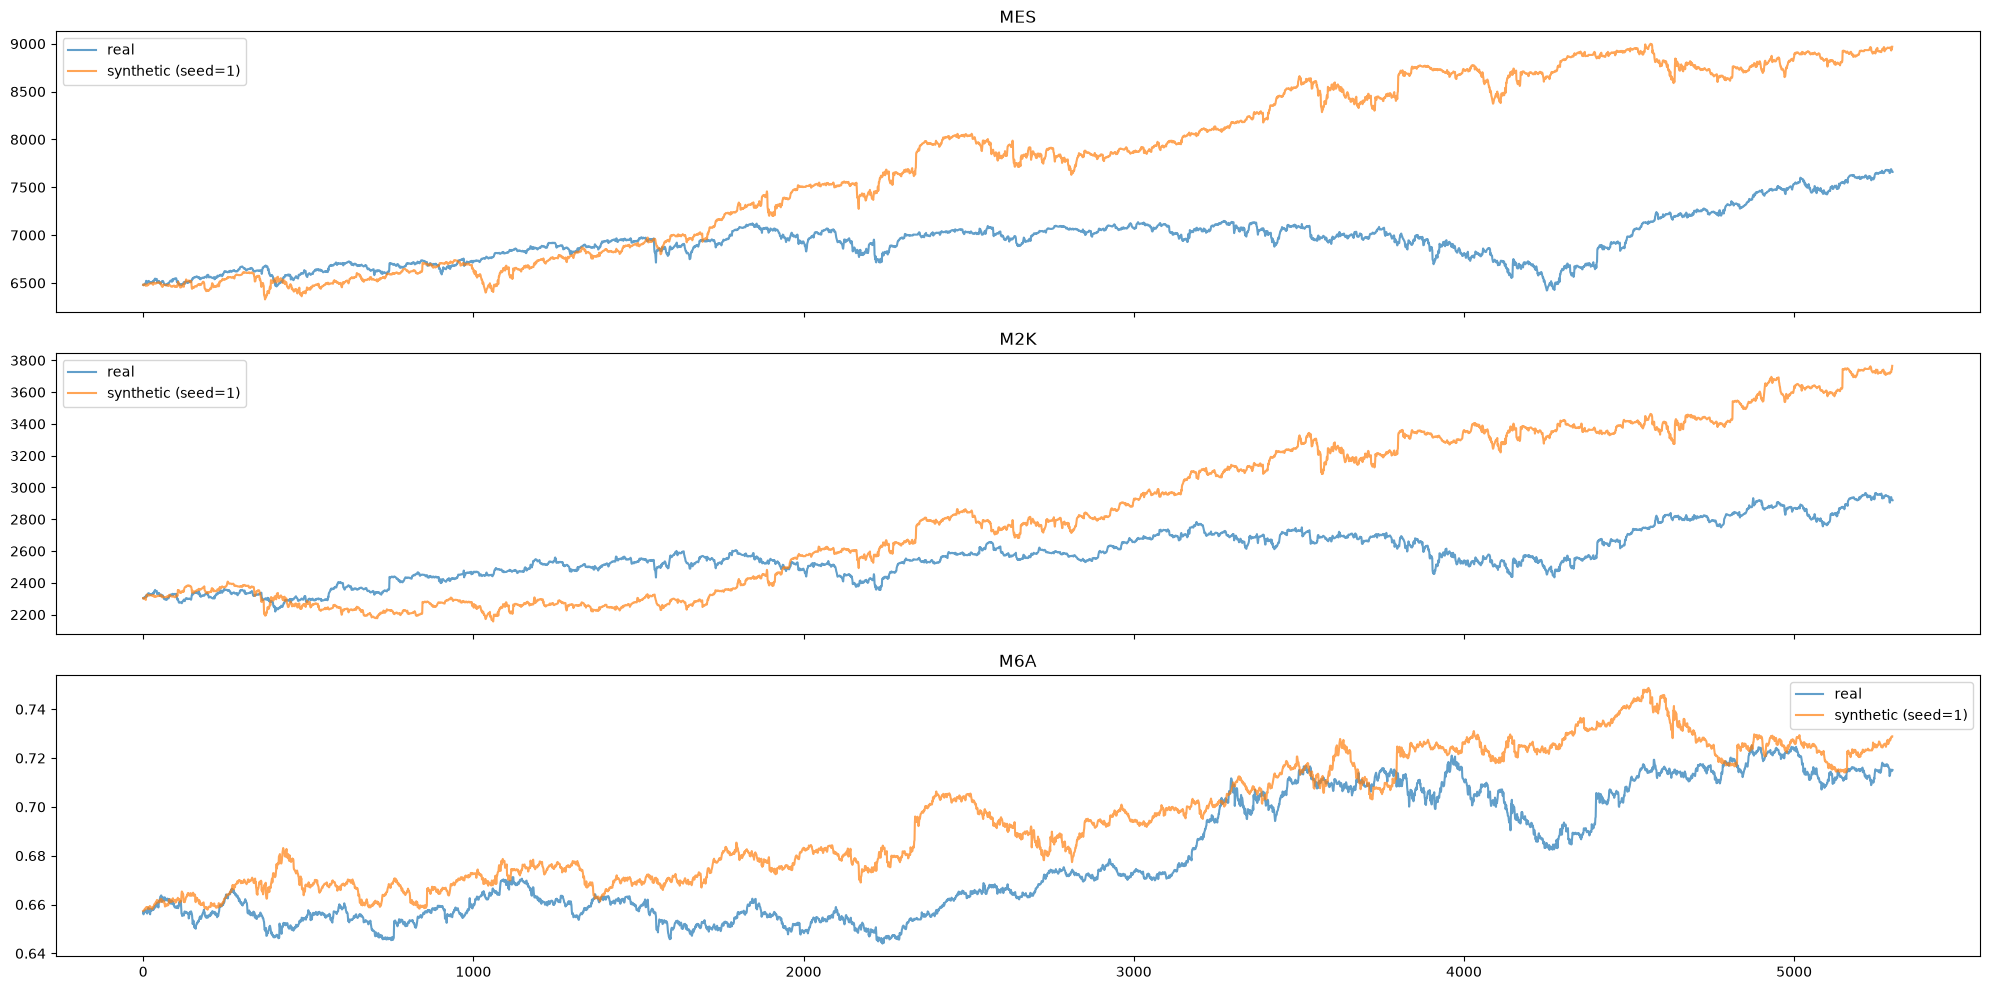

In [4]:

_sample = build_synthetic_run(seed=1)
for sym in SELECTED_SYMBOLS:
    real_close = real_ohlc[sym]["close"]
    synth_close = _sample[sym]["close"]
    real_ret = real_close.pct_change().dropna()
    synth_ret = synth_close.pct_change().dropna()
    print(f"{sym}: real ann.vol={real_ret.std()*np.sqrt(24*365):.3f}  "
          f"synthetic ann.vol={synth_ret.std()*np.sqrt(24*365):.3f}  "
          f"real total_return={real_close.iloc[-1]/real_close.iloc[0]-1:+.2%}  "
          f"synthetic total_return={synth_close.iloc[-1]/synth_close.iloc[0]-1:+.2%}")

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True)
for ax, sym in zip(axes, SELECTED_SYMBOLS):
    ax.plot(real_ohlc[sym]["close"].to_numpy(), label="real", alpha=0.7)
    ax.plot(_sample[sym]["close"].to_numpy(), label="synthetic (seed=1)", alpha=0.7)
    ax.set_title(sym)
    ax.legend()
plt.tight_layout()


In [5]:

def run_combined_backtest(ohlc_by_symbol: dict[str, pd.DataFrame]) -> dict:
    """Rebuilds the exact combined.ipynb hand-picked-combo backtest (3 fixed
    strategies/parameters, real costs, ~1-contract-each leveraged sizing, lock-aware
    Tradeify drawdown middleware, $50k deposit) on whichever OHLC is passed in."""
    market = Market()
    strategies = []

    for sym in SELECTED_SYMBOLS:
        cfg = INSTRUMENT_CONFIGS[sym]
        symbol = f"{sym}/USD"
        ohlc = ohlc_by_symbol[sym]
        market.add_market(symbol=symbol, df=ohlc)
        market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=cfg["fast_name"], df=cfg["fast_fn"](ohlc))
        market.add_indicator(symbol=symbol, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                              indicator_name=cfg["slow_name"], df=cfg["slow_fn"](ohlc))
        strategies.append(WeightedStrategy(
            weight=WEIGHTS[sym],
            strategy=MaCrossoverStrategy(
                key=f"{cfg['fast_name']}_{cfg['slow_name']}_{sym}", market=market, symbol=symbol,
                direction=StrategyDirection.long,
                fast_indicator_key=cfg["fast_name"], slow_indicator_key=cfg["slow_name"],
                sl_percent=0.3, tp_percent=0.6, sl_enabled=True, tp_enabled=True,
            ),
        ))

    market.compile()
    portfolio = Portfolio(weighted_strategies=strategies, output_scale=1)

    # SYMBOLS_WITH_CEILING hard-caps MES/M2K/M6A at 1 contract each (see setup cell)
    # regardless of how much a given synthetic run's equity compounds.
    symbol_config_provider = TradovateSymbolConfigProvider(
        symbols=SYMBOLS_WITH_CEILING, default_fee_per_contract=0.0
    )
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=MAX_LEVERAGE,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
        leverage_aware_sizing=True,
    )
    # periods_per_year=252: real trading-days/year convention for futures (not 365,
    # only correct for a 24/7 crypto market) -- using 365 here previously inflated
    # every Sharpe/Sortino/annualized-volatility number by sqrt(365/252) =~ 1.20
    # (~20%). net_return_percent/max_drawdown_percent/calmar_ratio are unaffected.
    reporter = PerformanceAnalyzer(
        market=market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[f"{sym}/USD" for sym in SELECTED_SYMBOLS],
        periods_per_year=252,
    )
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.04)
    # Tradeify's real $1,250/day soft daily-loss pause on a $50k account (2.5% of
    # balance) -- previously not modeled anywhere in this pipeline.
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.025)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=ACCOUNT_BALANCE)
    backtest.run_all()

    report = reporter.generate_report()
    algo = report["algo"] if report else {}
    equity_curve = (
        reporter.merged["algo__cumulative_returns"].to_numpy()
        if reporter.merged is not None else np.full(TARGET_LENGTH, np.nan)
    )

    return {
        "net_return_percent": algo.get("net_return_percent", float("nan")),
        "sharpe_ratio": algo.get("sharpe_ratio", float("nan")),
        "sortino_ratio": algo.get("sortino_ratio", float("nan")),
        "calmar_ratio": algo.get("calmar_ratio", float("nan")),
        "max_drawdown_percent": algo.get("max_drawdown_percent", float("nan")),
        "closed_trades": algo.get("closed_trades", 0),
        "account_failed": drawdown_middleware.account_failed,
        "locked": drawdown_middleware.locked,
        "equity_curve": equity_curve,
    }


def run_one_monte_carlo_iteration(seed: int) -> dict:
    synthetic = build_synthetic_run(seed)
    result = run_combined_backtest(synthetic)
    result["seed"] = seed
    return result


### Run 1 real backtest first, as a sanity check


In [6]:

real_result = run_combined_backtest(real_ohlc)
print({k: v for k, v in real_result.items() if k != "equity_curve"})


{'net_return_percent': 15.19923999999433, 'sharpe_ratio': 1.6330811971005896, 'sortino_ratio': 2.625914097934772, 'calmar_ratio': 3.8178309669991215, 'max_drawdown_percent': -4.4814, 'closed_trades': 396.0, 'account_failed': False, 'locked': True}


In [7]:

##### Execute the Monte Carlo with multiprocessing -- same convention as the step_1
# grid searches (multiprocess.Pool + tqdm).
pool = mp.Pool(5, maxtasksperchild=20)
mc_results = list(tqdm(pool.imap(run_one_monte_carlo_iteration, range(N_RUNS)), total=N_RUNS))
pool.close()

mc_df = pd.DataFrame([{k: v for k, v in r.items() if k != "equity_curve"} for r in mc_results])
equity_curves = np.stack([r["equity_curve"] for r in mc_results])
mc_df.head()


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 1/1000 [00:00<11:26,  1.46it/s]

  1%|          | 6/1000 [00:01<03:17,  5.04it/s]

  1%|          | 7/1000 [00:01<03:38,  4.55it/s]

  1%|          | 11/1000 [00:01<02:25,  6.79it/s]

...

100%|█████████▉| 995/1000 [02:12<00:00,  7.30it/s]

100%|█████████▉| 998/1000 [02:12<00:00,  7.15it/s]

100%|██████████| 1000/1000 [02:12<00:00,  7.09it/s]

100%|██████████| 1000/1000 [02:12<00:00,  7.52it/s]

,net_return_percent,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown_percent,closed_trades,account_failed,locked,seed
0,16.695151,1.563447,2.789418,5.106194,-3.6833,392.0,False,True,0
1,27.952085,2.396718,4.103812,8.925275,-3.5484,379.0,False,True,1
2,19.495878,1.846889,3.007370,9.641278,-2.2813,405.0,False,True,2
3,15.882868,1.556342,2.559215,4.705183,-3.8011,387.0,False,True,3
4,21.883493,2.202035,3.687724,7.570450,-3.2652,376.0,False,True,4


## Headline numbers and distribution summary


In [8]:

p_breach = mc_df["account_failed"].mean()
p_profitable = (mc_df["net_return_percent"] > 0).mean()
p_locked = mc_df["locked"].mean()

print(f"P(breach) across {N_RUNS} resampled histories: {p_breach:.1%}")
print(f"P(net profitable): {p_profitable:.1%}")
print(f"P(reached the profit buffer that locks the drawdown floor): {p_locked:.1%}")
print(f"Real-history result for comparison: net_return={real_result['net_return_percent']:.2f}%, "
      f"sharpe={real_result['sharpe_ratio']:.2f}, failed={real_result['account_failed']}")

summary_cols = ["net_return_percent", "sharpe_ratio", "sortino_ratio", "calmar_ratio", "max_drawdown_percent", "closed_trades"]
mc_df[summary_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])


P(breach) across 1000 resampled histories: 26.7%
P(net profitable): 76.8%
P(reached the profit buffer that locks the drawdown floor): 79.1%
Real-history result for comparison: net_return=15.20%, sharpe=1.63, failed=False


,net_return_percent,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown_percent,closed_trades
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.969876,1.036961,1.831328,3.435418,-4.258244,327.958000
std,9.930655,1.108814,1.865635,3.621454,1.114988,123.520871
min,-5.099927,-2.034818,-2.099486,-1.218033,-9.601200,22.000000
5%,-3.496685,-0.958096,-1.199168,-0.910842,-6.409630,62.900000
25%,0.160775,0.049882,0.069879,0.029409,-4.810950,301.500000
50%,11.746000,1.250017,2.033944,3.044747,-4.132000,392.000000
75%,17.993081,1.847324,3.093301,5.486472,-3.506950,403.000000
95%,26.947742,2.546763,4.648837,9.815811,-2.670565,416.000000
max,50.128412,3.941866,9.110704,25.928060,-1.690000,439.000000


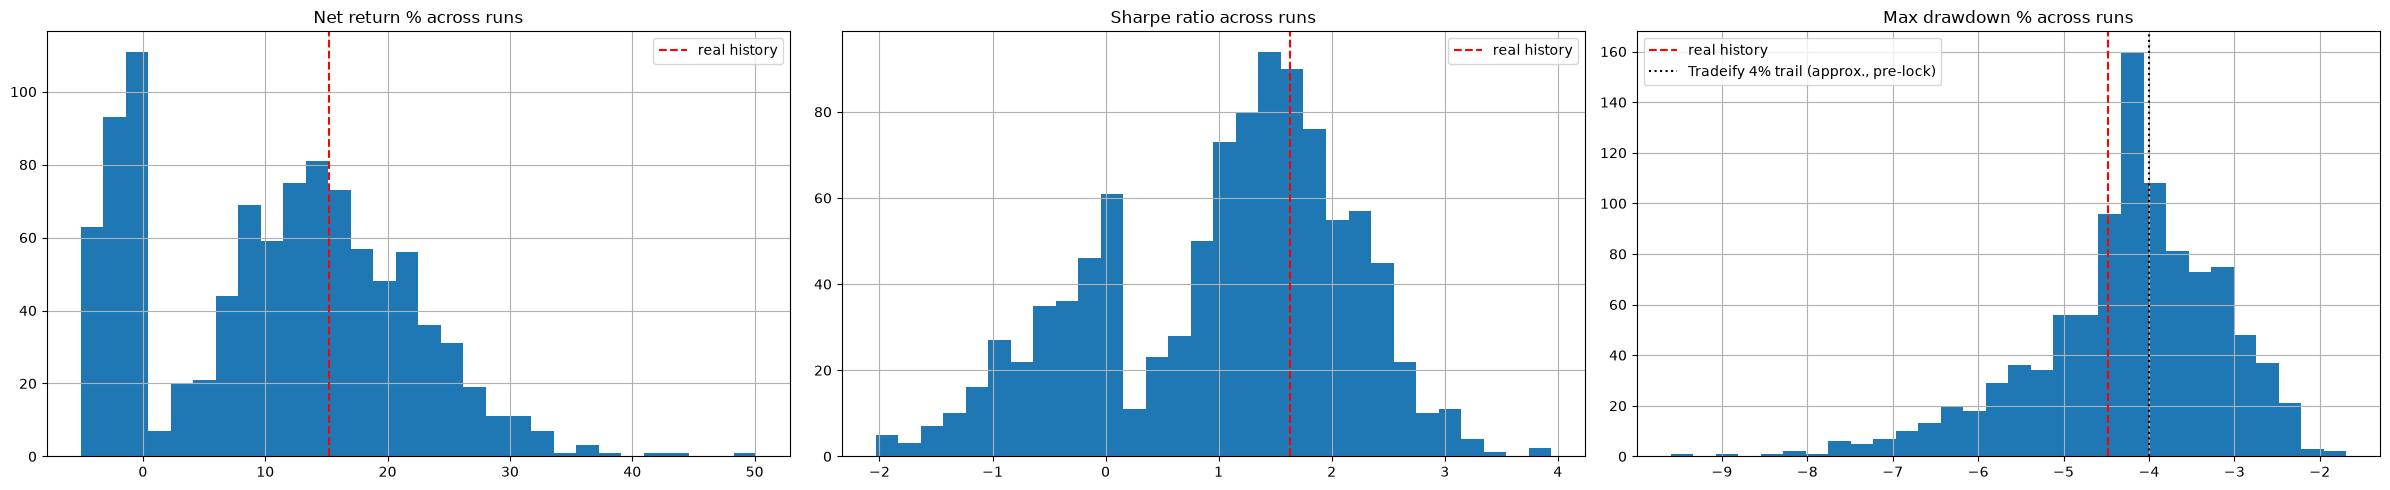

In [9]:

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
mc_df["net_return_percent"].hist(bins=30, ax=axes[0])
axes[0].axvline(real_result["net_return_percent"], color="red", linestyle="--", label="real history")
axes[0].set_title("Net return % across runs")
axes[0].legend()

mc_df["sharpe_ratio"].hist(bins=30, ax=axes[1])
axes[1].axvline(real_result["sharpe_ratio"], color="red", linestyle="--", label="real history")
axes[1].set_title("Sharpe ratio across runs")
axes[1].legend()

mc_df["max_drawdown_percent"].hist(bins=30, ax=axes[2])
axes[2].axvline(real_result["max_drawdown_percent"], color="red", linestyle="--", label="real history")
axes[2].axvline(-4.0, color="black", linestyle=":", label="Tradeify 4% trail (approx., pre-lock)")
axes[2].set_title("Max drawdown % across runs")
axes[2].legend()
plt.tight_layout()


## Equity curve overlay ("spaghetti" chart)


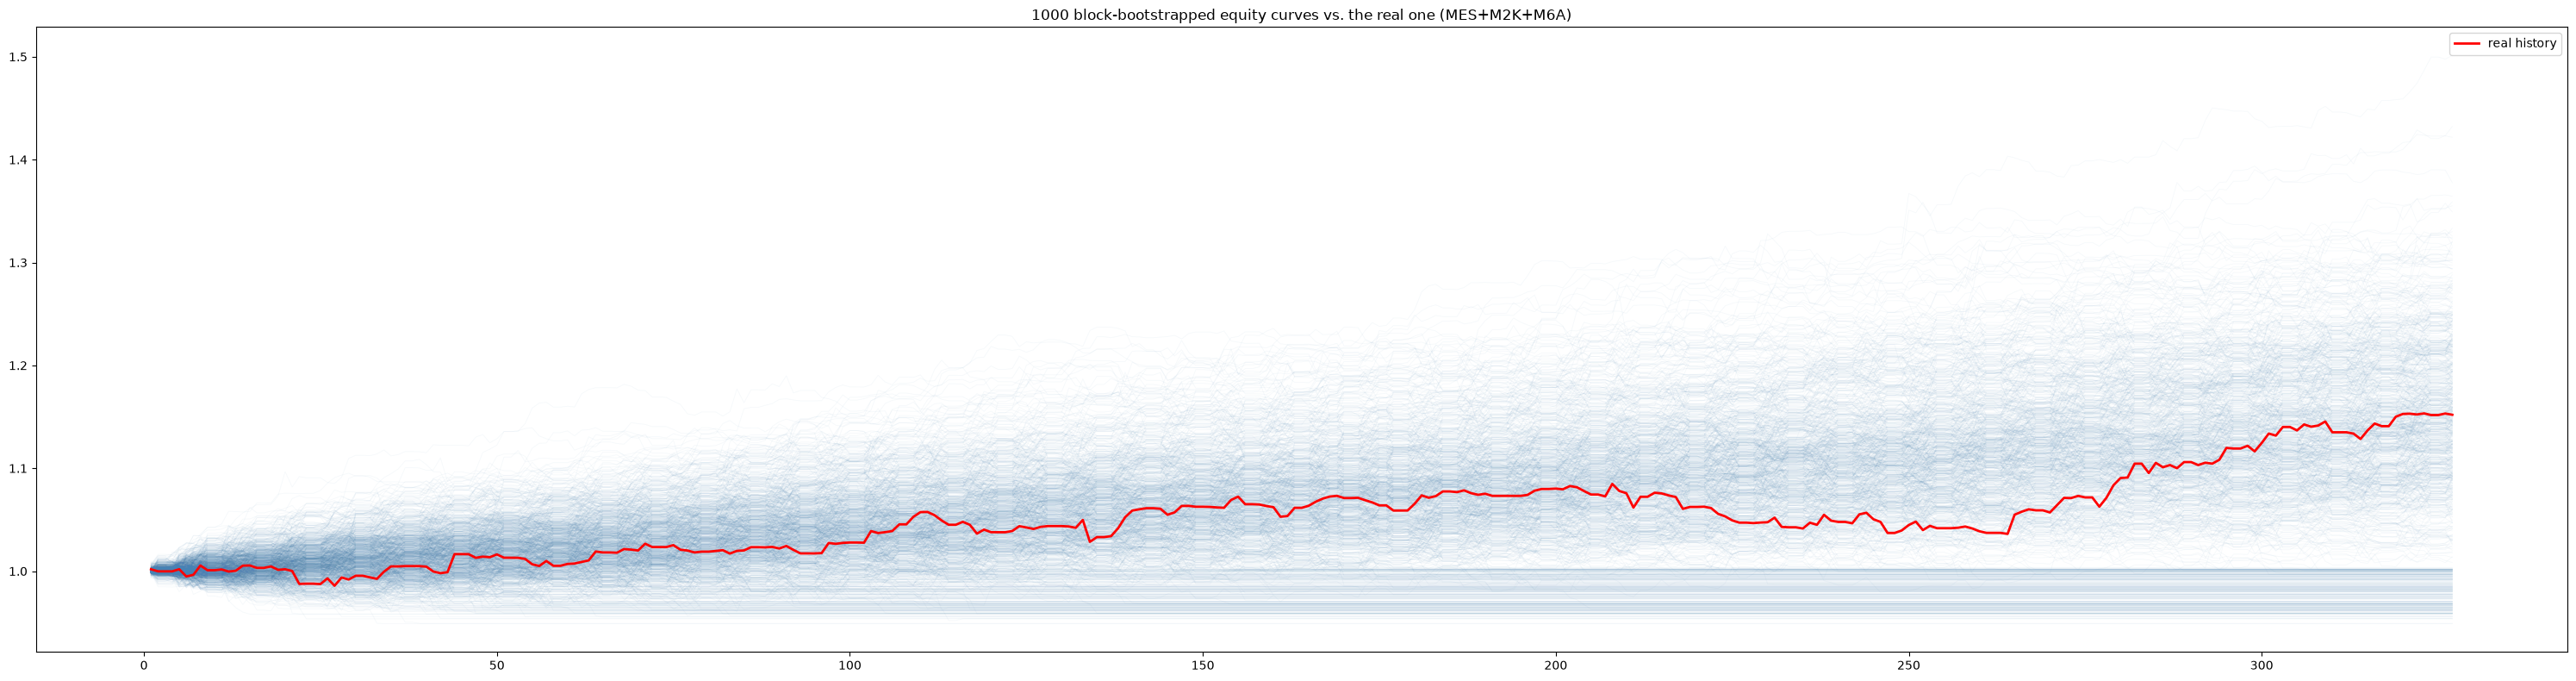

In [10]:

plt.figure(figsize=(30, 8))
for curve in equity_curves:
    plt.plot(curve, color="steelblue", alpha=0.05, linewidth=0.6)
plt.plot(real_result["equity_curve"], color="red", linewidth=2, label="real history")
plt.title(f"{N_RUNS} block-bootstrapped equity curves vs. the real one ({'+'.join(SELECTED_SYMBOLS)})")
plt.legend()
plt.tight_layout()


## Caveats

- **Still bounded by ~1 year of real history** -- block-bootstrapping reshuffles what
  actually happened in the source window, it can't invent market conditions that
  never occurred in it.
- **This combination was hand-picked** (see `combined.ipynb`) specifically because
  all 3 instruments have genuine standalone edges and sizing is conservative
  (~1 contract each, `max_leverage=2`) -- this Monte Carlo tests whether that more
  conservative starting point is actually more robust than the earlier
  algorithmically-selected, more aggressively-leveraged MNQ+6J+M6A combination was
  (which had a 60% breach rate at 5x leverage). Compare the P(breach) number above
  directly against that number.
- **N=1000 still can't invent conditions outside the source window**, but does give
  a much tighter estimate of the tail probabilities than the earlier N=100 pass.
- **Different technique from `OPTIMIZATION_RESEARCH_PLAN.md` §7.2's original plan**,
  which proposed bootstrapping the strategy's own *output* return/trade sequence
  rather than its *input* prices -- both are legitimate and complementary.
- **`max_position_size=1` (see `setup`/`per_run_backtest`) hard-caps each instrument
  at 1 contract in every one of the 1000 runs**, not just the single real-history
  path -- some synthetic runs grow the account well past its starting $50k (up to
  +50% in this sample), which combined with a lower-priced block landing later in a
  run could otherwise have silently sized a position up to 2 contracts. This ceiling
  means the reported P(breach) actually reflects a strictly-1-contract-each strategy
  throughout, not an accidentally-more-leveraged one in the high-growth tail.
- **Sharpe/Sortino/annualized-volatility now use `periods_per_year=252`** (real
  trading days/year), not the `PerformanceAnalyzer` default of 365 (only correct for
  a 24/7 crypto market) -- this pipeline used the 365 default until this pass,
  inflating every such figure by sqrt(365/252) =~ 1.20 (~20%).
  net_return_percent/max_drawdown_percent/calmar_ratio/P(breach) were never affected.
- **Tradeify's real $1,250/day soft daily-loss pause is now modeled**
  (`MaxDailyLossMiddleware(max_loss_percent=0.025)`) in every one of the 1000 runs --
  previously absent from this pipeline entirely.
